In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [3]:
df=pd.read_csv("C:\\Users\\LENOVO\\Downloads\\placement (1).csv")

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [6]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

In [7]:
df.shape

(200, 2)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21696\1741734764.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


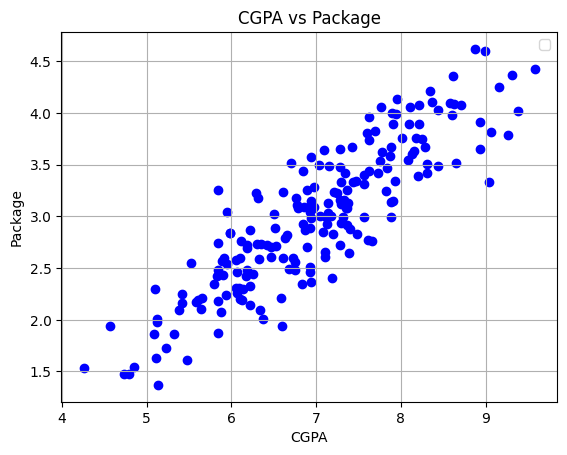

In [34]:
plt.scatter(df['cgpa'],df['package'],color='blue',marker='o')
plt.title('CGPA vs Package')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.legend()
plt.grid()
plt.show()

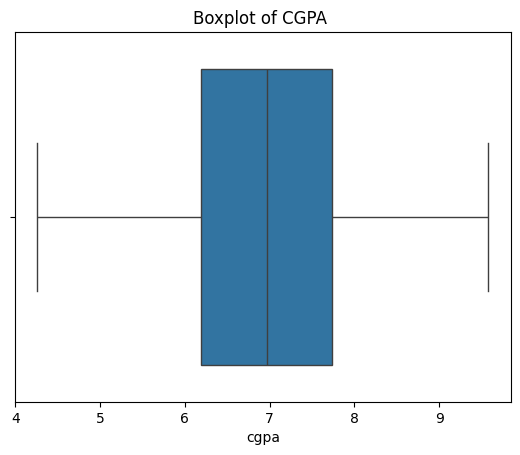

In [13]:
sns.boxplot(x='cgpa',data=df)
plt.title('Boxplot of CGPA ')
plt.show()

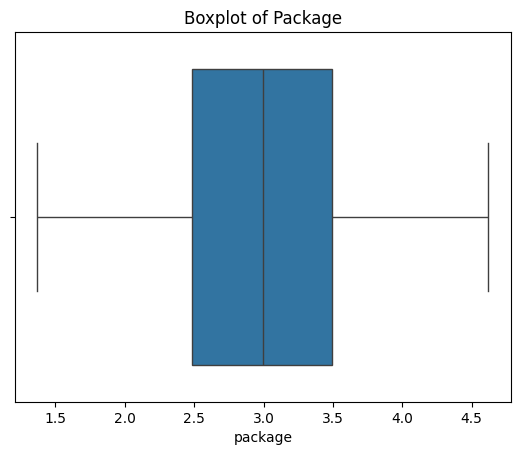

In [14]:
sns.boxplot(x='package',data=df)
plt.title('Boxplot of Package')
plt.show()

In [15]:
X=df[['cgpa']]
y=df[['package']]

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred=lr.predict(X_test)

In [21]:
compare_df=pd.DataFrame({'Actual':y_test.values.flatten(),'Predicted':y_pred.flatten()})
print(compare_df)

    Actual  Predicted
0     2.79   2.780313
1     3.23   3.136352
2     3.26   3.199521
3     3.04   2.389819
4     3.34   3.526847
5     4.21   3.768035
6     2.94   3.165065
7     2.87   2.544868
8     2.99   3.176550
9     3.58   3.492392
10    1.63   1.907444
11    2.08   2.349621
12    4.08   3.687639
13    2.21   2.757343
14    3.47   3.475164
15    3.64   3.044471
16    2.74   2.326651
17    3.08   3.205263
18    2.17   2.177344
19    2.99   3.314372
20    2.31   2.452987
21    2.35   2.900907
22    3.40   3.320115
23    3.08   2.872195
24    3.81   3.337342
25    2.19   2.194572
26    1.53   1.419326
27    2.89   2.711403
28    3.16   3.182293
29    2.48   2.326651
30    3.51   3.745064
31    2.98   2.958333
32    3.39   3.681896
33    3.28   2.975561
34    2.73   2.590809
35    3.74   3.348827
36    2.60   2.475958
37    3.13   3.073184
38    3.82   4.175757
39    3.15   2.958333


In [22]:
print("\nModel Evaluation:")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")



Model Evaluation:
R2 Score: 0.77
Mean Absolute Error: 0.23
Mean Squared Error: 0.08
Root Mean Squared Error: 0.29


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


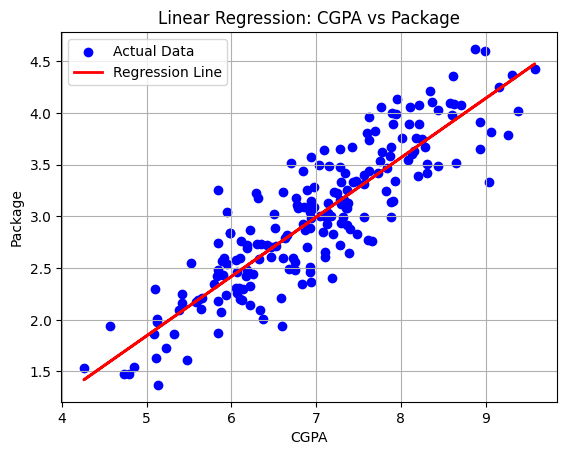

In [23]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, lr.predict(X.values.reshape(-1,1)), color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: CGPA vs Package')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.legend()
plt.grid()
plt.show()

In [32]:
user_cgpa = float(input("Enter CGPA for prediction: "))
predicted_package = lr.predict(np.array([[user_cgpa]]))
print(f"Predicted Package for CGPA {user_cgpa} is: {predicted_package[0][0]:.2f}")

Predicted Package for CGPA 10.0 is: 4.72


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


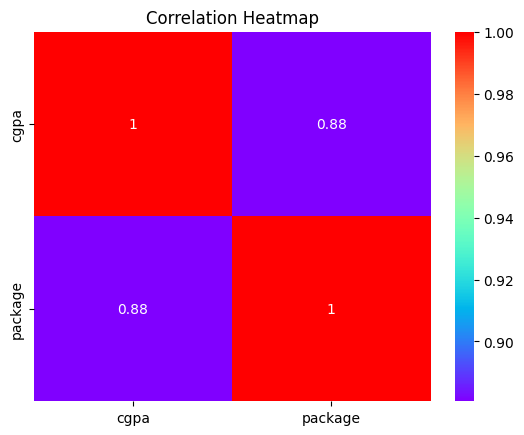

In [30]:
sns.heatmap(df.corr(), annot=True, cmap='rainbow')
plt.title('Correlation Heatmap')
plt.show()  